# Notebook for Atmospheric River data analysis

In [289]:
import warnings
warnings.filterwarnings("ignore")
import xarray as xr
import os
import urllib.request
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import matplotlib.animation as animation
from IPython.display import HTML, Video
import plotly.express as px
import io, base64
from PIL import Image
from ipyleaflet import Map, ImageOverlay, basemaps, ScaleControl
import ipywidgets as W
from xarray.coding.cftimeindex import CFTimeIndex  
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap, BoundaryNorm
from cartopy.mpl.gridliner import LongitudeFormatter, LatitudeFormatter

## Download Atmopheric River data from https://ar.pik-potsdam.de/

In [2]:
# Define the output directory: one level up from current working directory
output_dir = os.path.join(os.path.dirname(os.getcwd()), "data", "AR", "Eulerian")
os.makedirs(output_dir, exist_ok=True)

class DownloadProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)

years = range(1951, 2021 + 1)
locals_ = []

for y in years:
    url = f"https://ar.pik-potsdam.de/thredds/fileServer/eulerian_era5/PIKARTV1_eulerian_ERA5_0p5deg_6hr_{y}.nc"
    fname = os.path.join(output_dir, os.path.basename(url))
    
    print(f"\nDownloading {os.path.basename(fname)} to {output_dir}")
    with DownloadProgressBar(unit='B', unit_scale=True, miniters=1, desc=f"Year {y}") as t:
        urllib.request.urlretrieve(url, filename=fname, reporthook=t.update_to)
    
    locals_.append(fname)

print("\n✅ All files downloaded successfully!")

Year 1951: 328MB [00:15, 21.8MB/s]                              


Year 1952: 234MB [00:11, 20.6MB/s]                              


Year 1953: 286MB [00:12, 22.9MB/s]                              


Year 1954: 242MB [00:11, 20.3MB/s]                              


Year 1955: 287MB [00:12, 22.9MB/s]                              


...

Year 2018: 247MB [00:11, 21.0MB/s]                              


Year 2019: 246MB [00:11, 21.0MB/s]                              


Year 2020: 259MB [00:12, 21.0MB/s]                              


Year 2021: 282MB [00:12, 22.3MB/s]                              


✅ All files downloaded successfully!


In [3]:
# Open locally (no DAP), concat by coords
ds = xr.open_mfdataset(locals_, combine="by_coords")

## Get the AR mask for each time step (6hr)

In [22]:
ar_mask = ds['ar_mask']

In [23]:
ar_mask = ar_mask.where(ar_mask != 0, np.nan)

In [25]:
ar_mask = ar_mask.compute()

## This is for animation for the AR mask worldwide - takes around 50 minutes to run

da = ar_mask  # keep 1s, turn 0s into NaN

# Handle dim names
lat_name = "latitude" if "latitude" in da.dims else "lat"
lon_name = "longitude" if "longitude" in da.dims else "lon"

lats = da[lat_name].values
lons = da[lon_name].values
times = np.array(da["time"].values)
nframes = da.sizes["time"]

# Leaflet bounds use [southWest(lat, lon), northEast(lat, lon)]
bounds = [(float(lats.min()), float(lons.min())),
          (float(lats.max()), float(lons.max()))]

# --- 2) Helper: render binary mask to PNG with transparency ---
def mask_to_dataurl(Z, color=(255, 0, 0, 255)):
    """
    Z: 2D array with NaN=transparent, non-NaN=opaque footprint
    color: RGBA tuple for the footprint color (default: red, fully opaque)
    """
    Z = np.asarray(Z)
    H, W = Z.shape
    R, G, B, A = color

    # Alpha: 255 where mask present (not NaN), 0 elsewhere
    alpha = np.where(np.isnan(Z), 0, 255).astype(np.uint8)

    RGBA = np.zeros((H, W, 4), dtype=np.uint8)
    RGBA[..., 0] = R
    RGBA[..., 1] = G
    RGBA[..., 2] = B
    RGBA[..., 3] = alpha

    img = Image.fromarray(RGBA, mode="RGBA")

    buf = io.BytesIO()
    img.save(buf, format="PNG", optimize=True)
    b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    return f"data:image/png;base64,{b64}"

# --- 3) Pre-render frames (fast and smooth playback) ---
frames = []
for i in tqdm(range(nframes), desc="Rendering AR mask frames", unit="frame"):
    Z = da.isel(time=i).values
    frames.append(mask_to_dataurl(Z, color=(255, 0, 0, 255)))  # red mask
    # Try (0, 0, 255, 255) for blue, etc.

# --- 4) Build ipyleaflet map ---
m = Map(
    basemap=basemaps.Esri.WorldTopoMap,
    center=[(float(lats.min()) + float(lats.max())) / 2,
            (float(lons.min()) + float(lons.max())) / 2],
    zoom=5,
    scroll_wheel_zoom=True,
)

overlay = ImageOverlay(url=frames[0], bounds=bounds, opacity=1.0)  # opacity=1.0; transparency comes from per-pixel alpha
m.add(overlay)

# --- 5) UI controls (play, slider, date label) ---
play = W.Play(value=0, min=0, max=nframes - 1, step=1, interval=60, description="▶")
slider = W.IntSlider(value=0, min=0, max=nframes - 1, step=1, readout=False, layout=W.Layout(width="70%"))
W.jslink((play, "value"), (slider, "value"))

date_lbl = W.HTML(
    value=f"<b>Date:</b> {np.datetime_as_string(times[0], unit='D')}",
    layout=W.Layout(width="30%")
)

def on_change(change):
    i = change["new"]
    overlay.url = frames[i]
    date_lbl.value = f"<b>Date:</b> {np.datetime_as_string(times[i], unit='D')}"

slider.observe(on_change, names="value")

W.VBox([m, W.HBox([play, slider, date_lbl])])

## Extract the variable "IVT", select the region of California, select two different time periods 1991-2020 and 1951-1980, and sum the hourly values to daily

In [28]:
ivt = ds['ivt']

In [31]:
ivt_1991_2020 = ivt.sel(time=slice('1991-01-01', '2020-12-31'),  longitude=slice(-124.53, -114.13), latitude=slice(32.53, 42.00))

In [96]:
ivt_1951_1980 = ivt.sel(time=slice('1951-01-01', '1980-12-31'),  longitude=slice(-124.53, -114.13), latitude=slice(32.53, 42.00))

In [33]:
ivt_1991_2020 = ivt_1991_2020.resample(time='1D').sum() 

In [97]:
ivt_1951_1980 = ivt_1951_1980.resample(time='1D').sum() 

In [35]:
ivt_1991_2020_sum = ivt_1991_2020.sum(dim=["latitude", "longitude"])

# 2. (Optional) Load into memory if using dask
ivt_1991_2020_sum = ivt_1991_2020_sum.compute()

In [98]:
ivt_1951_1980_sum = ivt_1951_1980.sum(dim=["latitude", "longitude"])

# 2. (Optional) Load into memory if using dask
ivt_1951_1980_sum = ivt_1951_1980_sum.compute()

In [65]:
df_1991_2020 = ivt_1991_2020_sum.to_dataframe(name="Total_IVT").reset_index()

In [99]:
df_1951_1980 = ivt_1951_1980_sum.to_dataframe(name="Total_IVT").reset_index()

## Time series of daily IVT (summed over the entire domain of CA for the two different time periods)

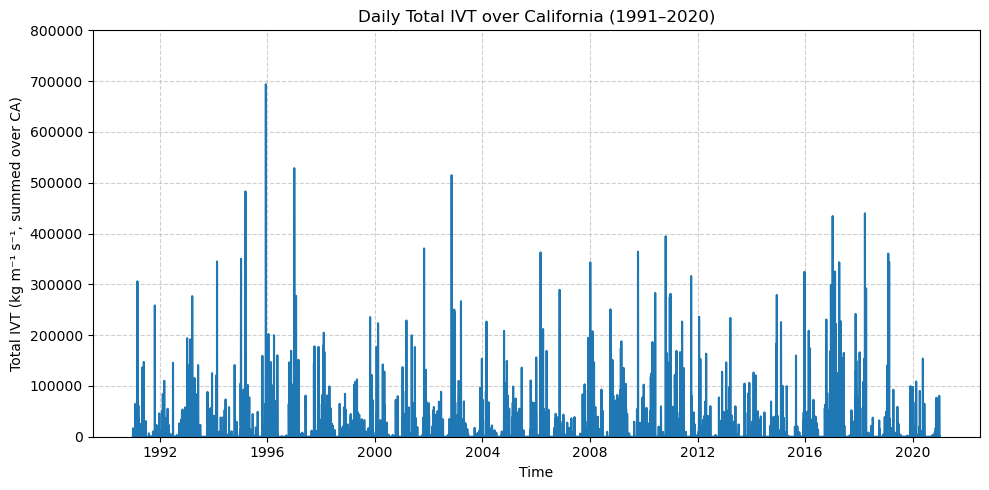

In [102]:
plt.figure(figsize=(10, 5))
ivt_1991_2020_sum.plot(color='tab:blue')

plt.title("Daily Total IVT over California (1991–2020)")
plt.xlabel("Time")
plt.ylabel("Total IVT (kg m⁻¹ s⁻¹, summed over CA)")
plt.ylim(0, 800000)  # ✅ equivalent to vmin/vmax for 1D plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


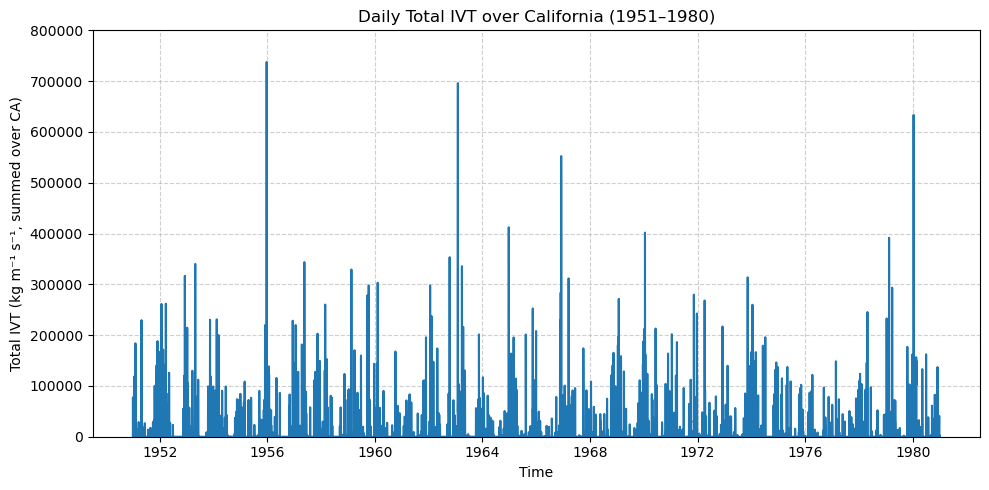

In [103]:
plt.figure(figsize=(10, 5))
ivt_1951_1980_sum.plot(color='tab:blue')

plt.title("Daily Total IVT over California (1951–1980)")
plt.xlabel("Time")
plt.ylabel("Total IVT (kg m⁻¹ s⁻¹, summed over CA)")
plt.ylim(0, 800000)  # ✅ equivalent to vmin/vmax for 1D plot
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## From the daily IVT time series for the two different time periods, we get the top five AR events for each

In [68]:
top5_1991_2020 = df_1991_2020.sort_values("Total_IVT", ascending=False).head(5)
top5_dates_1991_2020 = top5_1991_2020["time"].dt.strftime("%Y-%m-%d").tolist()
print(top5_dates_1991_2020)

['1995-12-12', '1997-01-01', '2002-11-08', '1995-03-10', '2018-03-22']


In [104]:
top5_1951_1980 = df_1951_1980.sort_values("Total_IVT", ascending=False).head(5)
top5_dates_1951_1980 = top5_1951_1980["time"].dt.strftime("%Y-%m-%d").tolist()
print(top5_dates_1951_1980)

['1955-12-23', '1963-02-01', '1980-01-12', '1963-01-31', '1966-12-05']


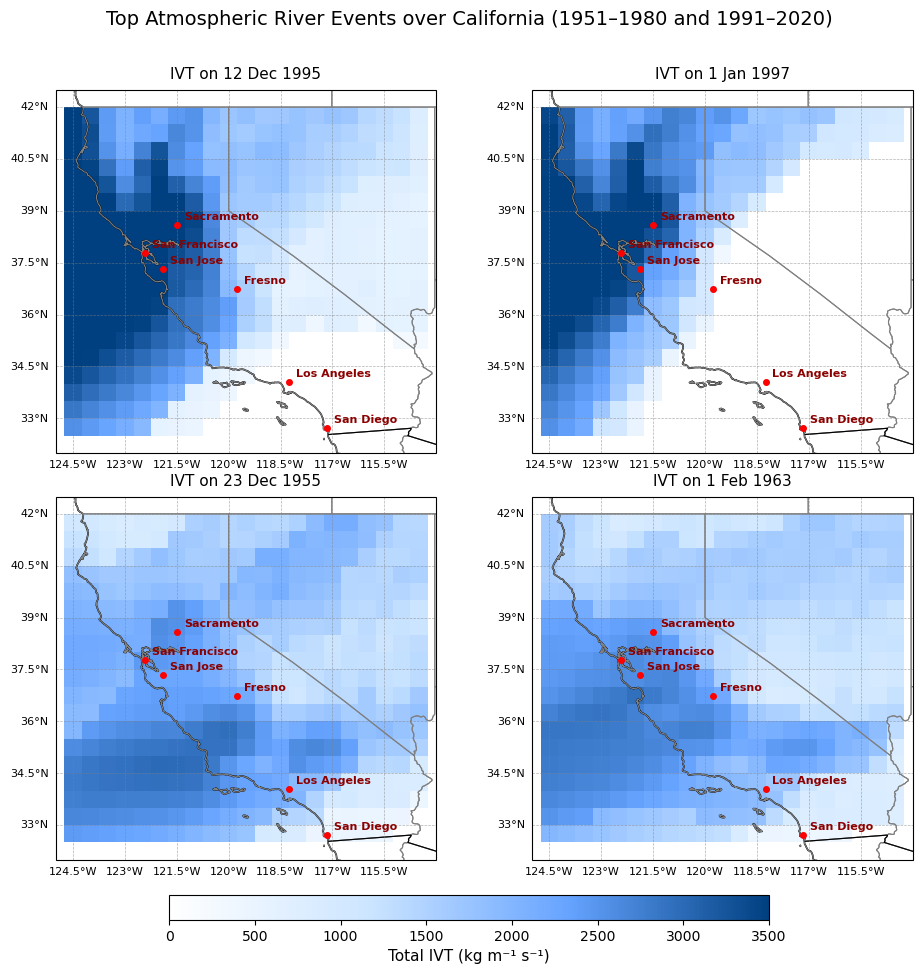

In [291]:
# --- Custom white-to-dark-blue colormap ---
colors = ["#ffffff", "#cce5ff", "#66a3ff", "#004080"]
white_to_darkblue = LinearSegmentedColormap.from_list("white_to_darkblue", colors, N=256)

# --- Select datasets and events ---
# Historical period (1951–1980)
da_hist = top_5_ivt_1951_1980
event_h1 = da_hist.sel(time="1955-12-23")
event_h2 = da_hist.sel(time="1963-02-01")

# Modern period (1991–2020)
da_mod = top_5_ivt_1991_2020
event_m1 = da_mod.sel(time="1995-12-12")
event_m2 = da_mod.sel(time="1997-01-01")

# --- Common plotting parameters ---
extent = [-125, -114, 32, 42.5]
vmin, vmax = 0, 3500

# --- Create 2x2 subplot ---
fig, axes = plt.subplots(
    2, 2, figsize=(12, 10),
    subplot_kw={"projection": ccrs.PlateCarree()},
    gridspec_kw={"wspace": 0.05, "hspace": 0.12}
)

plots = [
    (event_m1, "IVT on 12 Dec 1995"),
    (event_m2, "IVT on 1 Jan 1997"),
    (event_h1, "IVT on 23 Dec 1955"),
    (event_h2, "IVT on 1 Feb 1963")
]

# --- Major California cities ---
cities = {
    "Los Angeles": (34.05, -118.25),
    "San Diego": (32.72, -117.16),
    "San Francisco": (37.77, -122.42),
    "Sacramento": (38.58, -121.49),
    "Fresno": (36.74, -119.77),
    "San Jose": (37.33, -121.89)
}

# --- Loop over subplots ---
for ax, (data, title) in zip(axes.flat, plots):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black')
    ax.add_feature(cfeature.STATES, linewidth=0.8, edgecolor='gray')
    ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='black')

    # Plot IVT field
    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=white_to_darkblue,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # Add cities
    for name, (lat, lon) in cities.items():
        ax.plot(lon, lat, 'o', color='red', markersize=4, transform=ccrs.PlateCarree(), zorder=5)
        ax.text(lon + 0.2, lat + 0.15, name,
                fontsize=8, fontweight='bold', color='darkred',
                transform=ccrs.PlateCarree(), zorder=6)

    # --- Add gridlines with labels ---
    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.6,
        linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()
    gl.xlabel_style = {"size": 8, "color": "black"}
    gl.ylabel_style = {"size": 8, "color": "black"}

    ax.set_title(title, fontsize=11, pad=8)

cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.025])  # lowered from 0.07 to 0.05
cb = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cb.set_label("Total IVT (kg m⁻¹ s⁻¹)", fontsize=11)

# --- Figure title and layout (reduce spacing below title) ---
fig.suptitle("Top Atmospheric River Events over California (1951–1980 and 1991–2020)",
             fontsize=14, y=0.96)  # slightly lowered from 0.97
plt.tight_layout(rect=[0, 0.08, 1, 0.94])  # reduced bottom and top margins
plt.show()

In [69]:
ivt_1991_2020_na = ivt_1991_2020.where(ivt_1991_2020 != 0, np.nan)

In [106]:
ivt_1951_1980_na = ivt_1951_1980.where(ivt_1951_1980 != 0, np.nan)

In [346]:
da = ivt_1991_2020

lat_name = "latitude" if "latitude" in da.dims else "lat"
lon_name = "longitude" if "longitude" in da.dims else "lon"

if np.any(np.diff(da[lat_name].values) < 0):
    da = da.sel({lat_name: slice(da[lat_name].max(), da[lat_name].min())})

lats = da[lat_name].values
lons = da[lon_name].values
times = da["time"].values
nframes = da.sizes["time"]

# Value range and bounds
vmin, vmax = 0, 3500
bounds = [(float(lats.min()), float(lons.min())), (float(lats.max()), float(lons.max()))]

# -------------------------------------------------------------------
# 2. Colormap
# -------------------------------------------------------------------
cmap = plt.get_cmap("viridis")

# -------------------------------------------------------------------
# 3. Helper: convert 2D array → PNG data URL
# -------------------------------------------------------------------
def array_to_dataurl(Z, vmin, vmax, cmap):
    Z = np.asarray(Z, dtype=float)
    Z = np.clip((Z - vmin) / (vmax - vmin + 1e-12), 0, 1)

    # flip north-up because lat is ascending (south→north)
    Z = np.flipud(Z)

    RGBA = (cmap(Z) * 255).astype(np.uint8)
    img = Image.fromarray(RGBA, mode="RGBA")
    buf = io.BytesIO()
    img.save(buf, format="PNG", optimize=True)
    b64 = base64.b64encode(buf.getvalue()).decode("ascii")
    return f"data:image/png;base64,{b64}"


# -------------------------------------------------------------------
# 4. Pre-render frames
# -------------------------------------------------------------------
frames = []
for i in tqdm(range(nframes), desc="Rendering IVT frames", unit="frame"):
    Z = da.isel(time=i).values
    frames.append(array_to_dataurl(Z, vmin, vmax, cmap=cmap))

# -------------------------------------------------------------------
# 5. Create color scale image (horizontal bar)
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5, 0.4))
cb = plt.colorbar(
    plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax)),
    cax=ax,
    orientation="horizontal"
)
cb.set_label("Total IVT (kg m⁻¹ s⁻¹)")
plt.tight_layout()

buf = io.BytesIO()
plt.savefig(buf, format="png", bbox_inches="tight", dpi=150)
plt.close(fig)
colorbar_b64 = base64.b64encode(buf.getvalue()).decode("ascii")
colorbar_img = W.HTML(f'<img src="data:image/png;base64,{colorbar_b64}" width="400">')

# -------------------------------------------------------------------
# 6. ipyleaflet map with controls
# -------------------------------------------------------------------
m = Map(
    basemap=basemaps.Esri.WorldTopoMap,
    center=[(lats.min() + lats.max()) / 2, (lons.min() + lons.max()) / 2],
    zoom=5,
    scroll_wheel_zoom=True,
)
m.add_control(ScaleControl(position="bottomleft"))

overlay = ImageOverlay(url=frames[0], bounds=bounds, opacity=0.85)
m.add(overlay)

play = W.Play(value=0, min=0, max=nframes-1, step=1, interval=120, description="▶")
slider = W.IntSlider(value=0, min=0, max=nframes-1, step=1, readout=False, layout=W.Layout(width="70%"))
W.jslink((play, "value"), (slider, "value"))

date_lbl = W.HTML(
    value=f"<b>Date:</b> {np.datetime_as_string(times[0], unit='D')}",
    layout=W.Layout(width="30%")
)

def on_change(change):
    i = change["new"]
    overlay.url = frames[i]
    date_lbl.value = f"<b>Date:</b> {np.datetime_as_string(times[i], unit='D')}"

slider.observe(on_change, names="value")

# -------------------------------------------------------------------
# 7. Display with color scale below
# -------------------------------------------------------------------
W.VBox([
    m,
    colorbar_img,  # ✅ color scale displayed here
    W.HBox([play, slider, date_lbl])
])

Rendering IVT frames: 100%|██████████| 10958/10958 [02:54<00:00, 62.87frame/s]


In [78]:
top_5_ivt_1991_2020 = ivt_1991_2020.sel(time = ['1995-12-12', '1997-01-01', '2002-11-08', '1995-03-10', '2018-03-22'])

In [107]:
top_5_ivt_1951_1980 = ivt_1951_1980.sel(time = ['1955-12-23', '1963-02-01', '1980-01-12', '1963-01-31', '1966-12-05'])

In [91]:
top_5_ivt_1991_2020_mean = top_5_ivt_1991_2020.mean(dim = 'time')
top_5_ivt_1991_2020_mean

<xarray.DataArray 'ivt' (latitude: 19, longitude: 21)> Size: 2kB
dask.array<mean_agg-aggregate, shape=(19, 21), dtype=float32, chunksize=(19, 21), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 76B 32.75 33.25 33.75 ... 40.75 41.25 41.75
  * longitude  (longitude) float32 84B -124.5 -124.0 -123.5 ... -115.0 -114.5

In [108]:
top_5_ivt_1951_1980_mean = top_5_ivt_1951_1980.mean(dim = 'time')
top_5_ivt_1951_1980_mean

<xarray.DataArray 'ivt' (latitude: 19, longitude: 21)> Size: 2kB
dask.array<mean_agg-aggregate, shape=(19, 21), dtype=float32, chunksize=(19, 21), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float32 76B 32.75 33.25 33.75 ... 40.75 41.25 41.75
  * longitude  (longitude) float32 84B -124.5 -124.0 -123.5 ... -115.0 -114.5

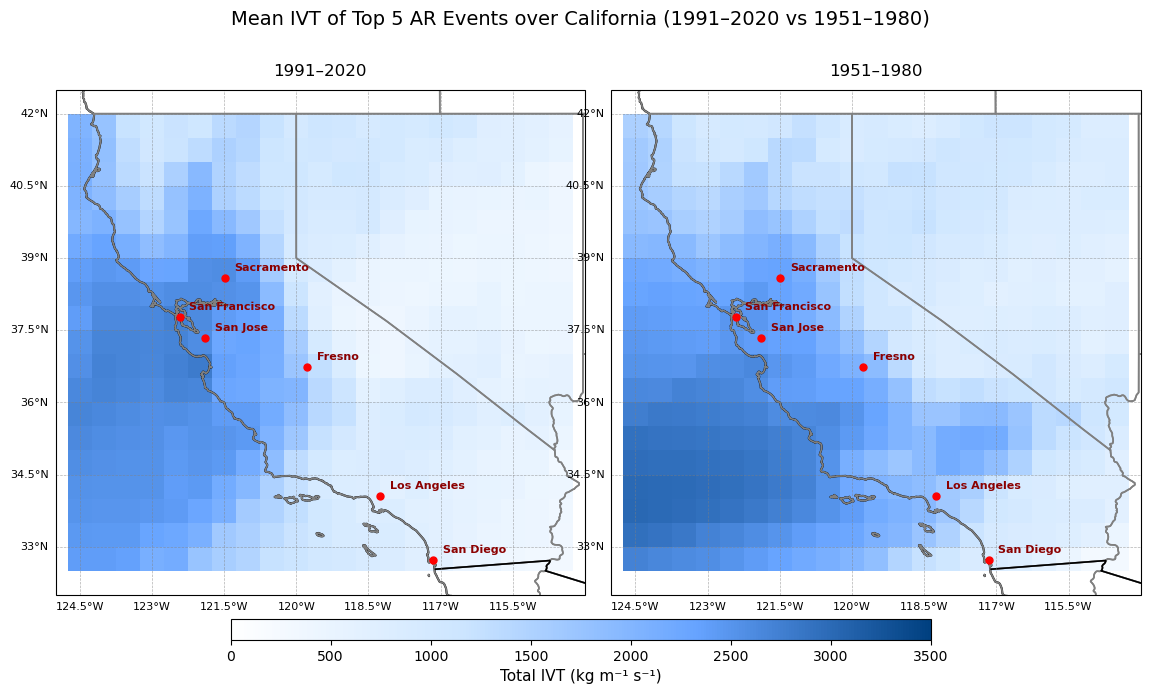

In [319]:

# --- Custom white-to-dark-blue colormap ---
colors = ["#ffffff", "#cce5ff", "#66a3ff", "#004080"]
white_to_darkblue = LinearSegmentedColormap.from_list("white_to_darkblue", colors, N=256)

# Common settings
extent = [-125, -114, 32, 42.5]
vmin, vmax = 0, 3500

fig, axes = plt.subplots(
    1, 2, figsize=(14, 7),
    subplot_kw={"projection": ccrs.PlateCarree()},
    gridspec_kw={"wspace": 0.05}
)

datasets = [
    (top_5_ivt_1991_2020_mean, "1991–2020"),
    (top_5_ivt_1951_1980_mean, "1951–1980")
]

cities = {
    "Los Angeles": (34.05, -118.25),
    "San Diego": (32.72, -117.16),
    "San Francisco": (37.77, -122.42),
    "Sacramento": (38.58, -121.49),
    "Fresno": (36.74, -119.77),
    "San Jose": (37.33, -121.89)
}

for ax, (da, title) in zip(axes, datasets):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black')
    ax.add_feature(cfeature.STATES, linewidth=1.2, edgecolor='gray')
    ax.add_feature(cfeature.BORDERS, linewidth=1.2, edgecolor='black')

    # --- Plot IVT field ---
    im = da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=white_to_darkblue,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # --- Add cities ---
    for name, (lat, lon) in cities.items():
        ax.plot(lon, lat, 'o', color='red', markersize=5,
                transform=ccrs.PlateCarree(), zorder=5)
        ax.text(lon + 0.2, lat + 0.15, name,
                fontsize=8, fontweight='bold', color='darkred',
                transform=ccrs.PlateCarree(), zorder=6)

    # --- Add gridlines with coordinate labels ---
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.6,
        linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8, 'color': 'black'}
    gl.ylabel_style = {'size': 8, 'color': 'black'}
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    ax.set_title(title, fontsize=12, pad=10)

# Shared colorbar (centered below both)
cbar_ax = fig.add_axes([0.25, 0.07, 0.5, 0.03])
cb = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cb.set_label("Total IVT (kg m⁻¹ s⁻¹)", fontsize=11)

fig.suptitle("Mean IVT of Top 5 AR Events over California (1991–2020 vs 1951–1980)",
             fontsize=14, y=0.97)

# Reduce overall gaps
plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.subplots_adjust(wspace=0.03)

plt.show()

In [110]:
diff_mean_top_5_IVT = top_5_ivt_1991_2020_mean - top_5_ivt_1951_1980_mean

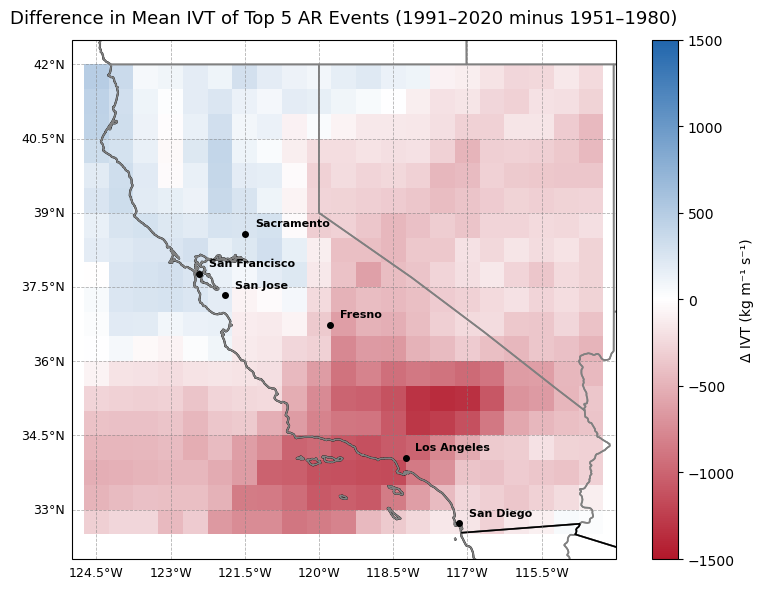

In [317]:
# --- Custom red–white–blue colormap ---
colors = ["#b2182b", "#ffffff", "#2166ac"]  # red → white → blue
red_white_blue = LinearSegmentedColormap.from_list("red_white_blue", colors, N=256)

# --- Create the figure and Cartopy axis centered on California ---
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Map extent around California
ax.set_extent([-125, -114, 32, 42.5], crs=ccrs.PlateCarree())

# --- Map features ---
ax.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black')
ax.add_feature(cfeature.STATES, linewidth=1.2, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=1.2, edgecolor='black')

# --- Plot difference field ---
im = diff_mean_top_5_IVT.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=red_white_blue,
    vmin=-1500,
    vmax=1500,
    cbar_kwargs={
        "label": "Δ IVT (kg m⁻¹ s⁻¹)"
    }
)

# --- Add major California cities ---
cities = {
    "Los Angeles": (34.05, -118.25),
    "San Diego": (32.72, -117.16),
    "San Francisco": (37.77, -122.42),
    "Sacramento": (38.58, -121.49),
    "Fresno": (36.74, -119.77),
    "San Jose": (37.33, -121.89)
}

for name, (lat, lon) in cities.items():
    ax.plot(lon, lat, 'o', color='black', markersize=4, transform=ccrs.PlateCarree(), zorder=5)
    ax.text(
        lon + 0.2, lat + 0.15, name,
        fontsize=8, fontweight='bold', color='black',
        transform=ccrs.PlateCarree(),
        zorder=6
    )

# --- Add coordinate gridlines and labels ---
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.6,
    color='gray',
    alpha=0.6,
    linestyle='--'
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9, 'color': 'black'}
gl.ylabel_style = {'size': 9, 'color': 'black'}
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

# --- Title and layout ---
ax.set_title("Difference in Mean IVT of Top 5 AR Events (1991–2020 minus 1951–1980)", fontsize=13, pad=12)

plt.tight_layout()
plt.show()

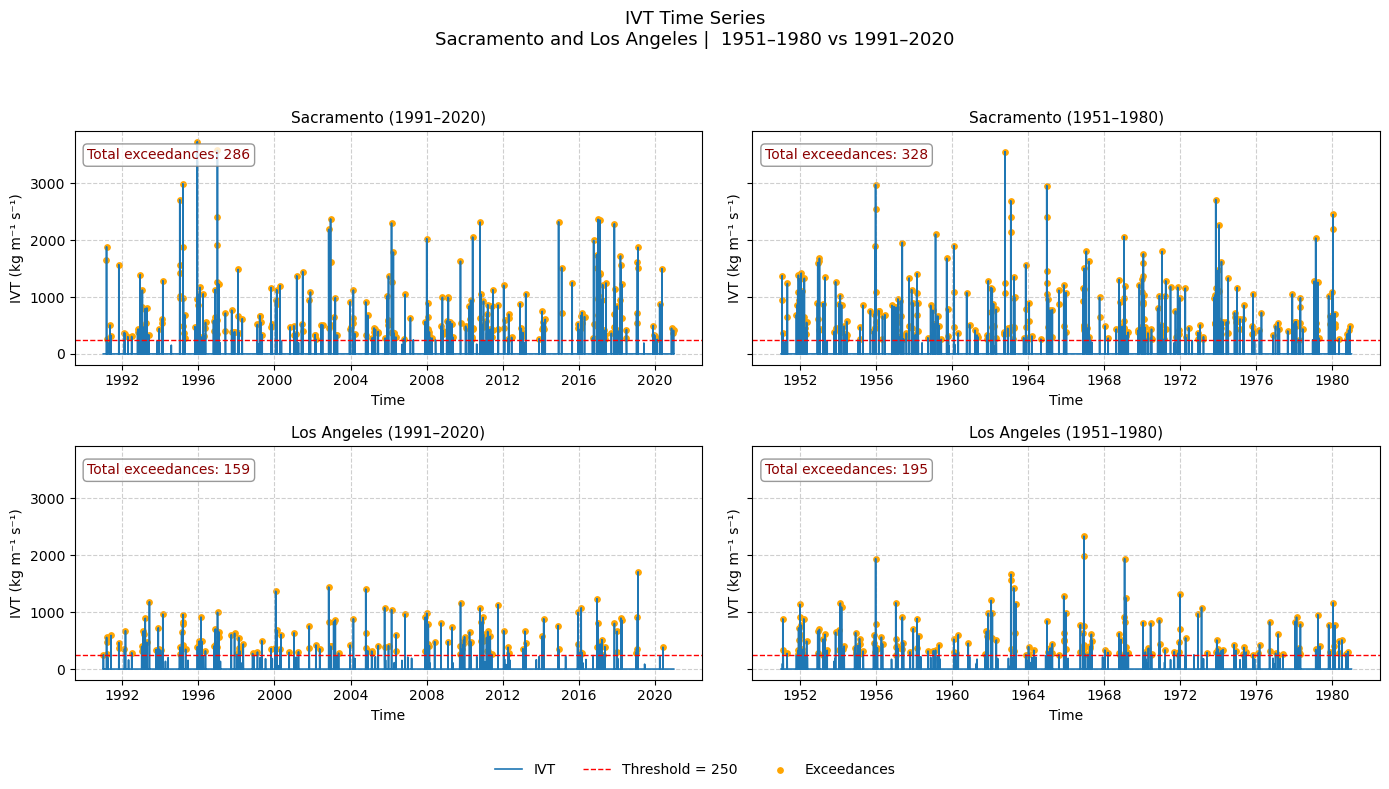

In [321]:
# --------------------------
# 1️⃣ Extract IVT for Sacramento and Los Angeles
# --------------------------
ivt_sac_1991_2020 = ivt_1991_2020.sel(latitude=38.58, longitude=-121.49, method="nearest")
ivt_sac_1951_1980 = ivt_1951_1980.sel(latitude=38.58, longitude=-121.49, method="nearest")

ivt_la_1991_2020 = ivt_1991_2020.sel(latitude=34.05, longitude=-118.25, method="nearest")
ivt_la_1951_1980 = ivt_1951_1980.sel(latitude=34.05, longitude=-118.25, method="nearest")

# --------------------------
# 2️⃣ Convert to DataFrames
# --------------------------
def ivt_to_df(ivt_da, label):
    df = ivt_da.to_dataframe(name="IVT").reset_index()
    df["Location_Period"] = label
    return df

dfs = [
    ivt_to_df(ivt_sac_1991_2020, "Sacramento (1991–2020)"),
    ivt_to_df(ivt_sac_1951_1980, "Sacramento (1951–1980)"),
    ivt_to_df(ivt_la_1991_2020, "Los Angeles (1991–2020)"),
    ivt_to_df(ivt_la_1951_1980, "Los Angeles (1951–1980)")
]


# --- Same figure setup as before ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=False, sharey=True)
axes = axes.flatten()

for ax, df_sub in zip(axes, dfs):
    num_exceedances = (df_sub["IVT"] > 250).sum()

    ax.plot(df_sub["time"], df_sub["IVT"], color="tab:blue", linewidth=1.2, label="IVT")
    ax.axhline(250, color="red", linestyle="--", linewidth=1, label="Threshold = 250")

    ax.scatter(
        df_sub.loc[df_sub["IVT"] > 250, "time"],
        df_sub.loc[df_sub["IVT"] > 250, "IVT"],
        color="orange", s=15, label="Exceedances"
    )

    ax.set_title(df_sub["Location_Period"].iloc[0], fontsize=11)
    ax.set_xlabel("Time")
    ax.set_ylabel("IVT (kg m⁻¹ s⁻¹)")
    ax.grid(True, linestyle="--", alpha=0.6)

    ax.text(
        0.02, 0.88,
        f"Total exceedances: {num_exceedances}",
        transform=ax.transAxes,
        fontsize=10,
        color="darkred",
        bbox=dict(facecolor="white", edgecolor="gray", boxstyle="round,pad=0.3", alpha=0.8)
    )

# --- Legend moved to bottom center ---
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=10, frameon=False)

# --- Adjust overall layout and spacing ---
fig.suptitle(
    "IVT Time Series\n"
    "Sacramento and Los Angeles |  1951–1980 vs 1991–2020",
    fontsize=13, y=0.97
)

plt.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.subplots_adjust(hspace=0.35, wspace=0.08)  # ✅ increased vertical spacing between rows
plt.show()


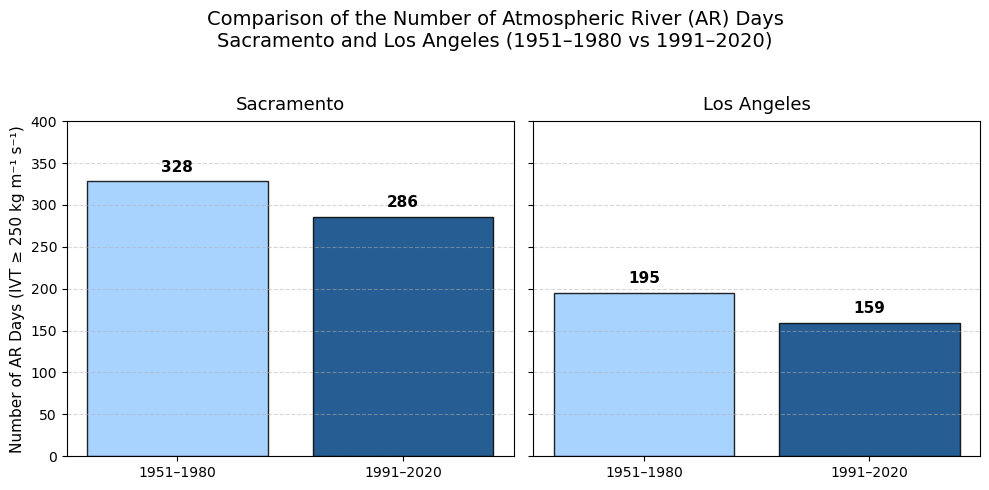

In [158]:
ar_counts = {
    "Sacramento": {"1951–1980": 328, "1991–2020": 286},
    "Los Angeles": {"1951–1980": 195, "1991–2020": 159}
}

locations = ["Sacramento", "Los Angeles"]
periods = ["1951–1980", "1991–2020"]

values = [
    [ar_counts["Sacramento"][p] for p in periods],
    [ar_counts["Los Angeles"][p] for p in periods]
]

# --- Plot setup ---
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
colors = ["#99ccff", "#004080"]  # lighter blue for better contrast
ymax = 400  # fixed vertical scaling for both plots

for ax, loc, vals in zip(axes, locations, values):
    bars = ax.bar(periods, vals, color=colors, alpha=0.85, edgecolor="black")

    # Annotate counts above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, height + 8,
            f"{int(height)}",
            ha="center", va="bottom", fontsize=11, fontweight="bold"
        )

    ax.set_title(f"{loc}", fontsize=13, pad=8)
    
    ax.set_ylim(0, ymax)
    ax.grid(axis="y", linestyle="--", alpha=0.5)

axes[0].set_ylabel("Number of AR Days (IVT ≥ 250 kg m⁻¹ s⁻¹)", fontsize=11)

# --- Overall title and layout ---
fig.suptitle(
    "Comparison of the Number of Atmospheric River (AR) Days\nSacramento and Los Angeles (1951–1980 vs 1991–2020)",
    fontsize=14, y=0.97
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## Download data from ERA5

In [244]:
%%time 
use_DE = True
#use_DE = False
if (use_DE):
  era5 = xr.open_dataset(
  'https://data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-v0.zarr', 
  chunks={}, storage_options={"client_kwargs":{"trust_env":True}}, consolidated=True, engine="zarr"
  )

else:
    ra5 = xr.open_dataset(
    'gs://weatherbench2/datasets/era5/1959-2023_01_10-wb13-6h-1440x721.zarr', 
     chunks = {'time':48}, consolidated = True, engine="zarr"
    )
print(f'size: {era5.nbytes / (1024 ** 4)} TB')

size: 363.4133632196099 TB
CPU times: user 122 ms, sys: 11.1 ms, total: 133 ms
Wall time: 1.59 s


In [245]:
era5

<xarray.Dataset> Size: 400TB
Dimensions:     (valid_time: 751680, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-09-30T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    surface     float64 8B ...
Data variables: (12/128)
    alnid       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    alnip       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    aluvp       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    anor        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    asn         (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    ...          ...
    viiwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwd       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwe       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    vilwn       (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    z           (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
    zust        (valid_time, latitude, longitude) float32 3TB dask.array<chunksize=(4320, 64, 64), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2025-02-13T19:10 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [246]:
era5_tp = era5['tp']

In [247]:
lonW = -124.53
lonE = -114.13
latS = 32.52
latN = 42.00

# ERA5 longitudes are 0..360
if lonW < 0:
    lonW = lonW + 360
if lonE < 0:
    lonE = lonE + 360

expand = 1  # degrees

# because latitude is stored decreasing, put the larger value first
lat_min = latS - expand   # 31.52
lat_max = latN + expand   # 43.00

era5_tp_1991_2020 = era5_tp.sel(
    latitude=slice(lat_max, lat_min),   # note: max → min
    longitude=slice(lonW - expand, lonE + expand), valid_time = slice('1991-01-01', '2020-12-31')
)

era5_tp_1951_1980 = era5_tp.sel(
    latitude=slice(lat_max, lat_min),   # note: max → min
    longitude=slice(lonW - expand, lonE + expand), valid_time = slice('1951-01-01', '1980-12-31')
)

In [248]:
era5_tp_1991_2020 = era5_tp_1991_2020.groupby("valid_time.year").sum(dim="valid_time")

In [249]:
era5_tp_1951_1980 = era5_tp_1951_1980.groupby("valid_time.year").sum(dim="valid_time")

In [250]:
era5_tp_1991_2020 = era5_tp_1991_2020.compute()
era5_tp_1951_1980 = era5_tp_1951_1980.compute()

In [251]:
era5_tp_1991_2020_mean = era5_tp_1991_2020.sum(dim = 'year') / 30

In [252]:
era5_tp_1951_1980_mean = era5_tp_1951_1980.sum(dim = 'year') / 30

In [254]:
era5_tp_1951_1980_mean = era5_tp_1951_1980_mean * 1000

In [255]:
era5_tp_1991_2020_mean = era5_tp_1991_2020_mean * 1000

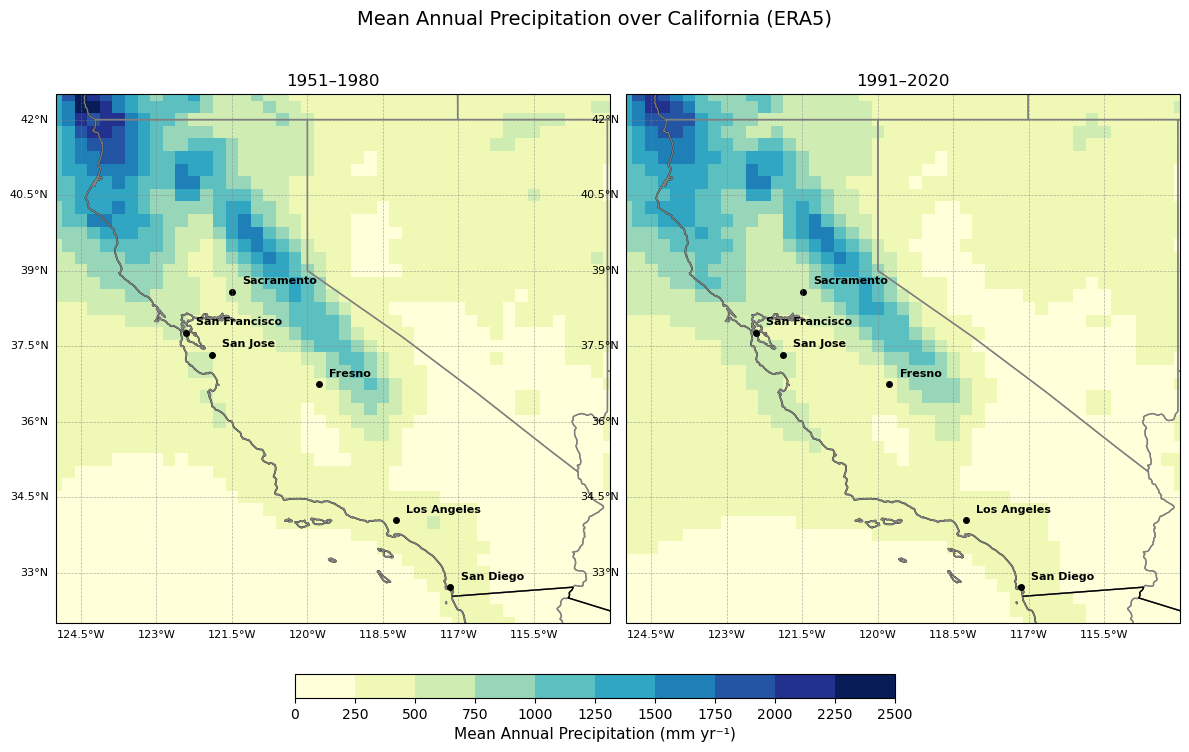

In [311]:
vmin, vmax = 0, 2500
bounds = np.arange(0, vmax + 250, 250)  # 0, 250, 500, ..., 2500
cmap = plt.get_cmap("YlGnBu", len(bounds) - 1)  # discrete version
norm = BoundaryNorm(bounds, cmap.N)

# --- Define map extent ---
extent = [-125, -114, 32, 42.5]

# --- Create 1×2 subplot ---
fig, axes = plt.subplots(
    1, 2, figsize=(12, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

# --- Periods and datasets ---
datasets = [
    (era5_tp_1951_1980_mean, "1951–1980"),
    (era5_tp_1991_2020_mean, "1991–2020")
]

# --- City coordinates ---
cities = {
    "Los Angeles": (34.05, -118.25),
    "San Diego": (32.72, -117.16),
    "San Francisco": (37.77, -122.42),
    "Sacramento": (38.58, -121.49),
    "Fresno": (36.74, -119.77),
    "San Jose": (37.33, -121.89)
}

# --- Plot loop ---
for ax, (da, title) in zip(axes, datasets):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black')
    ax.add_feature(cfeature.STATES, linewidth=1.0, edgecolor='gray')
    ax.add_feature(cfeature.BORDERS, linewidth=1.0, edgecolor='black')

    im = da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    # --- Add city markers and labels ---
    for name, (lat, lon) in cities.items():
        ax.plot(lon, lat, 'o', color='black', markersize=4, transform=ccrs.PlateCarree())
        ax.text(
            lon + 0.2, lat + 0.15, name,
            fontsize=8, fontweight='bold', color='black',
            transform=ccrs.PlateCarree()
        )

    # --- Add coordinate gridlines with labels ---
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.5,
        color='gray',
        alpha=0.6,
        linestyle='--'
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8, 'color': 'black'}
    gl.ylabel_style = {'size': 8, 'color': 'black'}
    gl.xformatter = LongitudeFormatter()
    gl.yformatter = LatitudeFormatter()

    ax.set_title(title, fontsize=12, pad=6)

# --- Shared colorbar ---
cbar_ax = fig.add_axes([0.25, 0.09, 0.5, 0.03])
cb = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", ticks=bounds)
cb.set_label("Mean Annual Precipitation (mm yr⁻¹)", fontsize=11)

# --- Main title and layout ---
fig.suptitle("Mean Annual Precipitation over California (ERA5)", fontsize=14, y=0.95)
plt.tight_layout(rect=[0, 0.12, 1, 0.95])
plt.subplots_adjust(wspace=0.03)

plt.show()

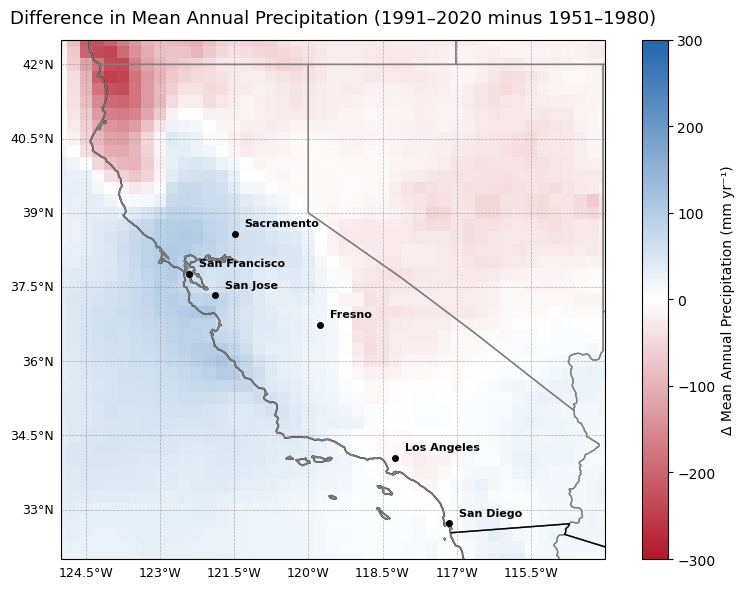

In [297]:
diff_mean_tp = era5_tp_1991_2020_mean - era5_tp_1951_1980_mean

# --- Custom red–white–blue colormap (drying → no change → wetter) ---
colors = ["#b2182b", "#ffffff", "#2166ac"]  # red = drier, blue = wetter
red_white_blue = LinearSegmentedColormap.from_list("red_white_blue", colors, N=256)

# --- Create the figure and Cartopy axis centered on California ---
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# --- Map extent around California ---
ax.set_extent([-125, -114, 32, 42.5], crs=ccrs.PlateCarree())

# --- Add map features ---
ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black')
ax.add_feature(cfeature.STATES, linewidth=1.0, edgecolor='gray')
ax.add_feature(cfeature.BORDERS, linewidth=1.0, edgecolor='black')

# --- Plot the difference field ---
im = diff_mean_tp.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=red_white_blue,
    vmin=-300,
    vmax=300,
    cbar_kwargs={
        "label": "Δ Mean Annual Precipitation (mm yr⁻¹)"
    }
)

# --- Add major California cities ---
cities = {
    "Los Angeles": (34.05, -118.25),
    "San Diego": (32.72, -117.16),
    "San Francisco": (37.77, -122.42),
    "Sacramento": (38.58, -121.49),
    "Fresno": (36.74, -119.77),
    "San Jose": (37.33, -121.89)
}

for name, (lat, lon) in cities.items():
    ax.plot(lon, lat, 'o', color='black', markersize=4, transform=ccrs.PlateCarree(), zorder=5)
    ax.text(
        lon + 0.2, lat + 0.15, name,
        fontsize=8, fontweight='bold', color='black',
        transform=ccrs.PlateCarree(), zorder=6
    )

# --- Add coordinate gridlines with labels ---
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.6,
    linestyle='--'
)
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 9, 'color': 'black'}
gl.ylabel_style = {'size': 9, 'color': 'black'}

# Format longitude and latitude labels
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
gl.xformatter = LongitudeFormatter()
gl.yformatter = LatitudeFormatter()

# --- Title and layout ---
ax.set_title(
    "Difference in Mean Annual Precipitation (1991–2020 minus 1951–1980)",
    fontsize=13, pad=12
)

plt.tight_layout()
plt.show()


In [305]:
era5_tp_CA_1991_2020 = era5_tp.sel(
    latitude=slice(lat_max, lat_min),   # note: max → min
    longitude=slice(lonW - expand, lonE + expand), valid_time = slice('1991-01-01', '2020-12-31')
)

In [306]:
era5_tp_CA_1951_1980 = era5_tp.sel(
    latitude=slice(lat_max, lat_min),   # note: max → min
    longitude=slice(lonW - expand, lonE + expand), valid_time = slice('1951-01-01', '1980-12-31')
)

In [307]:
# city coords
sac_coords = dict(latitude=38.58, longitude=-121.49)
la_coords  = dict(latitude=34.05, longitude=-118.25)

def daily_flag_df(ds, coords):
    """
    ds: xarray DataArray/DataSet with tp in meters, hourly, coord 'valid_time'
    coords: dict(latitude=..., longitude=...)
    returns: df with columns ['date', 'above_90th']
    """
    da = ds.sel(**coords, method="nearest")

    # hourly m -> daily mm
    daily_mm = (da * 1000).resample(valid_time="1D").sum()

    # 90th percentile for this location & period
    p90 = np.percentile(daily_mm.values, 90)

    df = pd.DataFrame({
        "date": daily_mm["valid_time"].dt.floor("D").values,
        "above_90th": daily_mm.values > p90
    })
    return df, p90

# 1) Sacramento, 1951–1980
df_sac_1951_1980, p90_sac_1951_1980 = daily_flag_df(era5_tp_CA_1951_1980, sac_coords)

# 2) Sacramento, 1991–2020
df_sac_1991_2020, p90_sac_1991_2020 = daily_flag_df(era5_tp_CA_1991_2020, sac_coords)

# 3) Los Angeles, 1951–1980
df_la_1951_1980, p90_la_1951_1980 = daily_flag_df(era5_tp_CA_1951_1980, la_coords)

# 4) Los Angeles, 1991–2020
df_la_1991_2020, p90_la_1991_2020 = daily_flag_df(era5_tp_CA_1991_2020, la_coords)

In [326]:
# --- Helper: make daily summed IVT DataFrame ---
def daily_ivt_sum_flag(ivt_da):
    """
    Converts hourly IVT (kg m⁻¹ s⁻¹) into daily-summed values
    and flags whether daily-sum > 250.
    """
    ivt_daily_sum = ivt_da.resample(time="1D").sum()  # daily sum of IVT
    df_ivt = pd.DataFrame({
        "date": ivt_daily_sum["time"].dt.floor("D").values,
        "ivt_gt_250": (ivt_daily_sum.values > 250)
    })
    return df_ivt

# --- Sacramento ---
df_ivt_sac_1951_1980 = daily_ivt_sum_flag(ivt_sac_1951_1980)
df_ivt_sac_1991_2020 = daily_ivt_sum_flag(ivt_sac_1991_2020)

# --- Los Angeles ---
df_ivt_la_1951_1980 = daily_ivt_sum_flag(ivt_la_1951_1980)
df_ivt_la_1991_2020 = daily_ivt_sum_flag(ivt_la_1991_2020)

# --- Merge IVT + rainfall (90th percentile) info ---
df_sac_1951_1980_merged = pd.merge(df_sac_1951_1980, df_ivt_sac_1951_1980, on="date", how="inner")
df_sac_1991_2020_merged = pd.merge(df_sac_1991_2020, df_ivt_sac_1991_2020, on="date", how="inner")
df_la_1951_1980_merged  = pd.merge(df_la_1951_1980,  df_ivt_la_1951_1980,  on="date", how="inner")
df_la_1991_2020_merged  = pd.merge(df_la_1991_2020,  df_ivt_la_1991_2020,  on="date", how="inner")

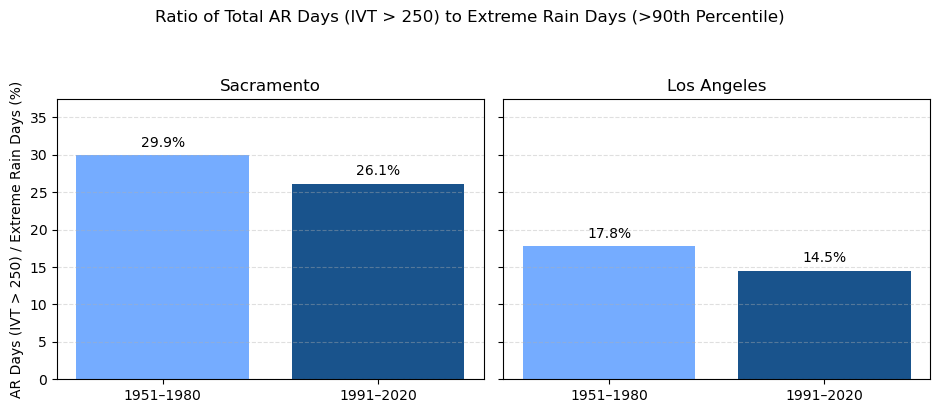

In [339]:
def ar_association(df):
    """
    Compute the ratio (in %) of total IVT>250 days to total extreme rainfall days (>90th percentile).
    """
    ivt_true = df["ivt_gt_250"].sum()      # total AR (IVT > 250) days
    rain_true = df["above_90th"].sum()     # total extreme rain (>90th) days
    if rain_true == 0:
        return np.nan
    return ivt_true / rain_true * 100


# --- Apply to all 4 merged DataFrames ---
sac_51_80 = ar_association(df_sac_1951_1980_merged)
sac_91_20 = ar_association(df_sac_1991_2020_merged)
la_51_80  = ar_association(df_la_1951_1980_merged)
la_91_20  = ar_association(df_la_1991_2020_merged)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4), sharey=True)
colors = ["#66a3ff", "#004080"]

# collect max across all four values
ymax = max(sac_51_80, sac_91_20, la_51_80, la_91_20) * 1.25  # 25% headroom

# Sacramento
axes[0].bar(["1951–1980", "1991–2020"], [sac_51_80, sac_91_20],
            color=colors, alpha=0.9)
for x, v in zip(["1951–1980", "1991–2020"], [sac_51_80, sac_91_20]):
    axes[0].text(x, v + ymax*0.02, f"{v:.1f}%", ha="center", va="bottom", fontsize=10)
axes[0].set_title("Sacramento")
axes[0].set_ylabel("AR Days (IVT > 250) / Extreme Rain Days (%)")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
axes[0].set_ylim(0, ymax)

# Los Angeles
axes[1].bar(["1951–1980", "1991–2020"], [la_51_80, la_91_20],
            color=colors, alpha=0.9)
for x, v in zip(["1951–1980", "1991–2020"], [la_51_80, la_91_20]):
    axes[1].text(x, v + ymax*0.02, f"{v:.1f}%", ha="center", va="bottom", fontsize=10)
axes[1].set_title("Los Angeles")
axes[1].grid(axis="y", linestyle="--", alpha=0.4)
axes[1].set_ylim(0, ymax)

fig.suptitle("Ratio of Total AR Days (IVT > 250) to Extreme Rain Days (>90th Percentile)",
             y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
